In [2]:
import torch
import torch.nn as nn
import numpy as np
from DDBSCAN import Raster_DBSCAN
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
from Models import *
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
import h5py

# from TrainSocialLSTM import extract_trajectories,prepare_training_data
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)

In [3]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import random
import glob

def process_traffic_context_data(
    source_dir,
    output_dir,
    input_frames=10,
    output_frames=12,
    train_samples=10000,
    val_samples=2000,
    seed=42
):
    """
    Process large traffic context data into smaller clips for Social-LSTM training
    
    Args:
        source_dir: Directory containing the original traffic context data
        output_dir: Directory to save processed data
        input_frames: Number of input frames per clip
        output_frames: Number of output frames per clip
        train_samples: Number of training samples to generate
        val_samples: Number of validation samples to generate
        seed: Random seed for reproducibility
    """
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    db = Raster_DBSCAN(Td_map_szie=(200,100), window_size=[3,9],eps = 1,min_samples=10)
    
    # Create output directories
    train_dir = os.path.join(output_dir, 'train')
    val_dir = os.path.join(output_dir, 'val')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    
    # Get list of traj_id files
    occupancy_files = glob.glob(os.path.join(source_dir, 'post_occ_label', '*.npy'))
    
    # Create H5PY files for training and validation
    train_h5_path = os.path.join(train_dir, 'social_lstm_data.h5')
    val_h5_path = os.path.join(val_dir, 'social_lstm_data.h5')
    print(f"Creating HDF5 files at {train_h5_path} and {val_h5_path}")
    with h5py.File(train_h5_path, 'w') as train_h5, h5py.File(val_h5_path, 'w') as val_h5:
        # Create datasets with maxshape parameter to allow resizing
        train_h5.create_dataset('traffic_context', # occupancy data
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('speed_data', 
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip", 
                              compression_opts=4)
        train_h5.create_dataset('metadata', 
                              shape=(train_samples, 3),  # [file_idx, start_frame, num_vehicles]
                              maxshape=(None, 3), # Allow resizing
                              dtype=np.int32,
                              chunks=(100, 3))
        # Create same datasets for validation
        val_h5.create_dataset('traffic_context', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        val_h5.create_dataset('speed_data', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('metadata', 
                            shape=(val_samples, 3),  # [file_idx, start_frame, num_vehicles]
                            maxshape=(None, 3), # Allow resizing
                            dtype=np.int32,
                            chunks=(100, 3))
        
        # Store source file names for reference
        train_h5.create_dataset('file_names', 
                              shape=(len(occupancy_files),),
                              dtype=h5py.special_dtype(vlen=str))
        val_h5.create_dataset('file_names', 
                            shape=(len(occupancy_files),),
                            dtype=h5py.special_dtype(vlen=str))
        
        for i, file_path in enumerate(occupancy_files):
            train_h5['file_names'][i] = os.path.basename(file_path)
            val_h5['file_names'][i] = os.path.basename(file_path)
        
        # Sample counter
        train_count = 0
        val_count = 0
        print( len(occupancy_files),'aa' )
        # Process each file and generate samples
        for file_idx, file_path in enumerate(tqdm(occupancy_files, desc="Processing files")):
            # Load trajectory ID data
            occupancy_data = np.load(file_path)
            
            # Try to load speed data if available
            try:
                speed_path = file_path.replace('traj_id_label', 'speed_label')
                speed_data = np.load(speed_path)
            except:
                # Create dummy speed data if not available
                speed_data = np.zeros_like(occupancy_data)
            
            traj_id_data = db.fit_predict(occupancy_data, Foreground_map=(occupancy_data == 1))  # Perform DBSCAN clustering
            # Get file shape
            lane_cells, time_span = occupancy_data.shape # 200, 100
            
            # Calculate number of possible starting frames
            max_start = time_span - (input_frames + output_frames) + 1
            
            if max_start <= 0:
                print(f"Skipping {file_path} - not enough frames")
                continue
            
            # Generate potential starting frames
            start_frames = list(range(0, max_start))
            random.shuffle(start_frames)
            
            # Select samples for this file
            file_train_count = min(100, len(start_frames) // 2)  # Limit samples per file
            file_val_count = min(20, len(start_frames) // 10)  # Limit validation samples per file
            # Generate training samples
            for i, start_frame in enumerate(start_frames[:file_train_count]):
                if train_count >= train_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles >= 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                train_h5['vehicle_id'][train_count] = traj_id_clip
                train_h5['traffic_context'][train_count] = occupancy_clip
                train_h5['speed_data'][train_count] = speed_clip
                train_h5['metadata'][train_count] = [file_idx, start_frame, num_vehicles]
                
                train_count += 1
                
                # Print progress
                if train_count % 1000 == 0:
                    print(f"Generated {train_count}/{train_samples} training samples")
            
            # Generate validation samples
            for i, start_frame in enumerate(start_frames[file_train_count:file_train_count + file_val_count]):
                if val_count >= val_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles > 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                val_h5['vehicle_id'][val_count] = traj_id_clip
                val_h5['traffic_context'][val_count] = occupancy_clip
                val_h5['speed_data'][val_count] = speed_clip
                val_h5['metadata'][val_count] = [file_idx, start_frame, num_vehicles]
                
                val_count += 1
                
                # Print progress
                if val_count % 500 == 0:
                    print(f"Generated {val_count}/{val_samples} validation samples")
            
            # Break if we have enough samples
            if train_count >= train_samples and val_count >= val_samples:
                break
        
        # Update dataset sizes if we didn't generate enough samples
        if train_count < train_samples:
            print(f"Only generated {train_count}/{train_samples} training samples")
            train_h5['vehicle_id'].resize((train_count, 200, input_frames + output_frames))
            train_h5['traffic_context'].resize((train_count, 200, input_frames + output_frames))
            train_h5['speed_data'].resize((train_count, 200, input_frames + output_frames))
            train_h5['metadata'].resize((train_count, 3))
        
        if val_count < val_samples:
            print(f"Only generated {val_count}/{val_samples} validation samples")
            val_h5['vehicle_id'].resize((val_count, 200, input_frames + output_frames))
            val_h5['traffic_context'].resize((val_count, 200, input_frames + output_frames))
            val_h5['speed_data'].resize((val_count, 200, input_frames + output_frames))
            val_h5['metadata'].resize((val_count, 3))
    
    print(f"Successfully processed data:")
    print(f"  - Training samples: {train_count}")
    print(f"  - Validation samples: {val_count}")
    print(f"  - Saved to: {output_dir}")

    return train_h5_path, val_h5_path

In [4]:
db = Raster_DBSCAN(Td_map_szie=(200,100), window_size=[5,9],eps = 1,min_samples=10)

In [5]:
file_path = r'D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train\post_occ_label\36_39_0_signal_1860.npy'
traffic_context = np.load(file_path)

In [6]:
id_map = db.fit_predict(traffic_context, Foreground_map=(traffic_context == 1))

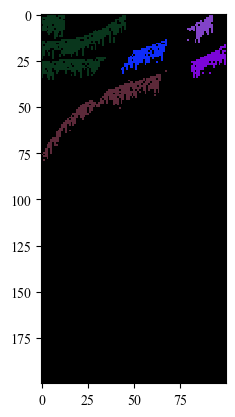

In [7]:
plt.imshow(id_map,cmap=colormap,interpolation='none')
plt.show()

In [ ]:
source_dir=r'D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train'
output_dir=r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset_50-25'
input_frames=50
output_frames=25
train_samples=30000
val_samples=4000
seed=714
process_traffic_context_data(source_dir, output_dir, input_frames, output_frames, train_samples, val_samples, seed)

In [11]:
from Dataset import MemoryMappedSocialLSTMDataset
from ModelSocial import LaneSocialLSTM
# from CriterionSocial import social_trajectory_loss

In [12]:
val_h5_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset\val\social_lstm_data.h5'
val_dataset = MemoryMappedSocialLSTMDataset(
        h5_path=val_h5_path,
        input_frames=50,
        output_frames=25
    )
val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        # num_workers=4,
        # pin_memory=True
    )

Preprocessing data from D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset\val\social_lstm_data.h5...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset\val\social_lstm_data.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [23]:
for batch in val_loader:
    input_positions, input_context, target_positions, output_distributions, output_masks = batch
    print(input_positions.shape, input_context.shape, target_positions.shape, output_distributions.shape, output_masks.shape)
    break  # Remove this to process all batches

torch.Size([32, 10]) torch.Size([32, 10, 200]) torch.Size([32, 1]) torch.Size([32, 1, 200]) torch.Size([32, 1])


In [27]:
input_positions.shape

torch.Size([32, 10])

In [26]:
input_context.shape

torch.Size([32, 10, 200])

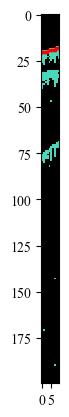

In [24]:
plt.imshow(input_context[0].cpu().numpy().T, cmap=colormap, interpolation='none')
# plot the input positions
plt.scatter(np.arange(10),input_positions[0].cpu().numpy(), color='red', marker='o', label='Input Positions', s = 3)
plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 0.001
weight_decay = 1e-5
model = LaneSocialLSTM(
    hidden_size=64,
    social_size=32,
    neighborhood_size=16,
    num_layers=1,
    input_frames=10,
    output_frames=1,
    lane_cells=200,
    dropout=0.2,
    device=device
).to(device)
model_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\models\social_lstm\train_0\best_model.pth'
model.load_state_dict(torch.load(model_path,weights_only=False)['model_state_dict'])

<All keys matched successfully>

In [ ]:

# Convert to numpy
input_pos = input_positions[idx].cpu().numpy()
input_ctx = input_context[idx].cpu().numpy()
pred_dist = pred_distributions[idx].cpu().numpy()

# Total number of frames
input_frames = input_pos.shape[0]
output_frames = pred_dist.shape[0]
total_frames = input_frames + output_frames

# Get expected positions from distributions
cell_positions = np.arange(lane_cells)
expected_positions = np.sum(pred_dist * cell_positions.reshape(1, -1), axis=1)

if target_positions is not None:
    target_pos = target_positions[idx].cpu().numpy()
    if output_masks is not None:
        mask = output_masks[idx].cpu().numpy()
    else:
        mask = np.ones_like(target_pos)
        
if target_distributions is not None:
    target_dist = target_distributions[idx].cpu().numpy()

# Create figure with subplots
fig = plt.figure(figsize=(15, 12))

# Plot input context (time-space diagram)
plt.subplot(3, 1, 1)
plt.imshow(input_ctx.T, aspect='auto', cmap='Blues', interpolation='none', 
            extent=[0, input_frames, lane_cells, 0])
plt.xlabel('Time Step')
plt.ylabel('Lane Cell Index')
plt.title('Input Traffic Context (Time-Space Diagram)')
plt.colorbar(label='Occupancy')

# Plot predicted distribution as heatmap
plt.subplot(3, 1, 2)
plt.imshow(pred_dist.T, aspect='auto', cmap='Reds', interpolation='none',
            extent=[input_frames, total_frames, lane_cells, 0])
plt.xlabel('Time Step')
plt.ylabel('Lane Cell Index')
plt.title('Predicted Position Distribution')
plt.colorbar(label='Probability')

In [52]:
prediction_distribution = model(input_positions.to(device), input_context.to(device))

In [58]:
# Compute loss
loss, js_loss, pos_loss = combined_distribution_loss(
    prediction_distribution, output_distributions.to(device), target_positions.to(device), output_masks.to(device)
)

In [59]:
loss

tensor(2580.6218, device='cuda:0', grad_fn=<AddBackward0>)